## Imports

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from tqdm.notebook import tqdm

## Подготовка df

In [37]:
ingredient_rating_columns = ['rating',
    'almond', 'amaretto', 'anchovy', 'anise', 'apple', 'apple juice', 'apricot',
    'artichoke', 'arugula', 'asian pear', 'asparagus', 'avocado',
    'bacon', 'banana', 'barley', 'basil', 'bass', 'bean', 'beef', 'beef rib',
    'beef shank', 'beef tenderloin', 'beer', 'beet', 'bell pepper', 'berry',
    'biscuit', 'bitters', 'blackberry', 'blue cheese', 'blueberry', 'bok choy',
    'bourbon', 'bran', 'brandy', 'bread', 'breadcrumbs', 'brie', 'brisket',
    'broccoli', 'broccoli rabe', 'brown rice', 'brownie', 'brussel sprout',
    'bulgur', 'butter', 'buttermilk', 'butternut squash', 'butterscotch/caramel',
    'cabbage', 'cake', 'calvados', 'campari', 'candy', 'cantaloupe', 'capers',
    'caraway', 'cardamom', 'carrot', 'cashew', 'cauliflower', 'caviar', 'celery',
    'chambord', 'champagne', 'chard', 'chartreuse', 'cheddar', 'cheese', 'cherry',
    'chestnut', 'chicken', 'chickpea', 'chile', 'chile pepper', 'chili', 'chive',
    'chocolate', 'cilantro', 'cinnamon', 'citrus', 'clam', 'clove', 'coconut',
    'cod', 'coffee', 'cognac/armagnac', 'collard greens', 'cookie', 'cookies',
    'coriander', 'corn', 'cornmeal', 'cottage cheese', 'couscous', 'crab',
    'cranberry', 'cranberry sauce', 'cream cheese', 'créme de cacao', 'crêpe',
    'cr��me de cacao', 'cucumber', 'cumin', 'cupcake', 'currant', 'curry',
    'date', 'dill', 'dried fruit', 'duck', 'eau de vie', 'egg', 'egg nog',
    'eggplant', 'endive', 'escarole', 'fennel', 'feta', 'fig', 'fish',
    'flat bread', 'fontina', 'fortified wine', 'frangelico',
    'fruit juice', 'game', 'garlic', 'gin', 'ginger', 'goat cheese', 'goose',
    'gouda', 'grains', 'grand marnier', 'granola', 'grape', 'grapefruit',
    'grappa', 'green bean', 'green onion/scallion', 'ground beef', 'ground lamb',
    'guava', 'halibut', 'ham', 'hazelnut', 'herb', 'hominy/cornmeal/masa',
    'honey', 'honeydew', 'horseradish', 'hot pepper', 'hummus', 'ice cream',
    'iced coffee', 'iced tea', 'jalapeño', 'jam or jelly', 'jerusalem artichoke',
    'jícama', 'kahlúa', 'kale', 'kirsch', 'kiwi', 'kumquat', 'lamb', 'lamb chop',
    'lamb shank', 'leafy green', 'leek', 'legume', 'lemon', 'lemon juice',
    'lemongrass', 'lentil', 'lettuce', 'lima bean', 'lime', 'lime juice',
    'lingonberry', 'liqueur', 'lobster', 'lychee', 'macadamia nut', 'mango',
    'maple syrup', 'marsala', 'marscarpone', 'marshmallow', 'mayonnaise', 'meat',
    'melon', 'mezcal', 'midori', 'milk/cream', 'mint', 'molasses', 'monterey jack',
    'mozzarella', 'muffin', 'mushroom', 'mussel', 'mustard', 'mustard greens',
    'nectarine', 'noodle', 'nut', 'nutmeg', 'oat', 'oatmeal', 'octopus', 'okra',
    'olive', 'onion', 'orange', 'orange juice', 'oregano', 'orzo', 'oyster',
    'pancake', 'papaya', 'paprika', 'parmesan', 'parsley', 'parsnip', 'passion fruit',
    'pasta', 'pastry', 'pea', 'peach', 'peanut', 'peanut butter', 'pear', 'pecan',
    'pepper', 'pernod', 'persimmon', 'phyllo/puff pastry dough', 'pickles',
    'pine nut', 'pineapple', 'pistachio', 'plantain', 'plum', 'poblano',
    'pomegranate', 'pomegranate juice', 'poppy', 'pork', 'pork chop', 'pork rib',
    'pork tenderloin', 'port', 'potato', 'poultry', 'poultry sausage', 'prosciutto',
    'prune', 'pumpkin', 'quail', 'quince', 'quinoa', 'rabbit', 'rack of lamb',
    'radicchio', 'radish', 'raisin', 'raspberry', 'red wine', 'rhubarb', 'rice',
    'ricotta', 'root vegetable', 'rosemary', 'rosé', 'rum', 'rutabaga', 'rye',
    'saffron', 'sage', 'sake', 'salmon', 'salsa', 'sangria', 'sardine', 'sausage',
    'scallop', 'scotch', 'seafood', 'seed', 'semolina', 'sesame', 'sesame oil',
    'shallot', 'shellfish', 'sherry', 'shrimp', 'smoothie', 'snapper', 'sorbet',
    'sour cream', 'sourdough', 'soy', 'soy sauce', 'sparkling wine', 'spice',
    'spinach', 'spirit', 'squash', 'squid', 'steak', 'stock', 'strawberry',
    'sugar snap pea', 'sweet potato/yam', 'swiss cheese', 'swordfish', 'tamarind',
    'tangerine', 'tapioca', 'tarragon', 'tea', 'tequila', 'thyme', 'tilapia',
    'tofu', 'tomatillo', 'tomato', 'tortillas', 'tree nut', 'triple sec',
    'tropical fruit', 'trout', 'tuna', 'turkey', 'turnip', 'vanilla', 'veal',
    'vegetable', 'venison', 'vermouth', 'vinegar', 'vodka', 'waffle', 'walnut',
    'wasabi', 'watercress', 'watermelon', 'whiskey', 'white wine', 'whole wheat',
    'wild rice', 'wine', 'yellow squash', 'yogurt', 'yuca', 'zucchini'
]
df = pd.read_csv("../kaggle/epi_r.csv")
df = df[ingredient_rating_columns]

In [38]:
prep_points = 0
max_prep_points = 0
# Условия с "нет" (отсутствие колонки)
if 'title' not in df.columns:
    prep_points += 1
max_prep_points += 1
if 'leftovers' not in df.columns:
    prep_points += 1
max_prep_points += 1 
if 'california' not in df.columns:
    prep_points += 1
max_prep_points += 1
if 'dominican republic' not in df.columns:
    prep_points += 1
max_prep_points += 1
if 'protein' not in df.columns:
    prep_points += 1
max_prep_points += 1
if 'low cholesterol' not in df.columns:
    prep_points += 1
max_prep_points += 1
if 'pan-fry' not in df.columns:
    prep_points += 1
max_prep_points += 1
if 'fruit' not in df.columns:
    prep_points += 1
max_prep_points += 1
if 'stew' not in df.columns:
    prep_points += 1
max_prep_points += 1
if 'braise' not in df.columns:
    prep_points += 1
max_prep_points += 1

# Условия с "есть" (наличие колонки)
if any(col in df.columns for col in ['milk', 'milk/cream']):
    prep_points += 1
max_prep_points += 1
if any(col in df.columns for col in ['jam', 'jam or jelly']):
    prep_points += 1
max_prep_points += 1


print(f"Итоговое количество очков подготовки: {prep_points}")
print(f"Максимальное количество очков подготовки: {max_prep_points}")

Итоговое количество очков подготовки: 12
Максимальное количество очков подготовки: 12


In [39]:
df.head()

,rating,almond,amaretto,anchovy,anise,apple,apple juice,apricot,artichoke,arugula,...,watermelon,whiskey,white wine,whole wheat,wild rice,wine,yellow squash,yogurt,yuca,zucchini
0,2.500,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,4.375,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.750,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,5.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,3.125,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [40]:
print(len(df.columns))
print(len(df))

359
20052


In [41]:
print(df['rating'].value_counts().sort_index(ascending=False))

rating
5.000    2719
4.375    8019
3.750    5169
3.125    1489
2.500     532
1.875     124
1.250     164
0.000    1836
Name: count, dtype: int64


<Axes: xlabel='rating'>

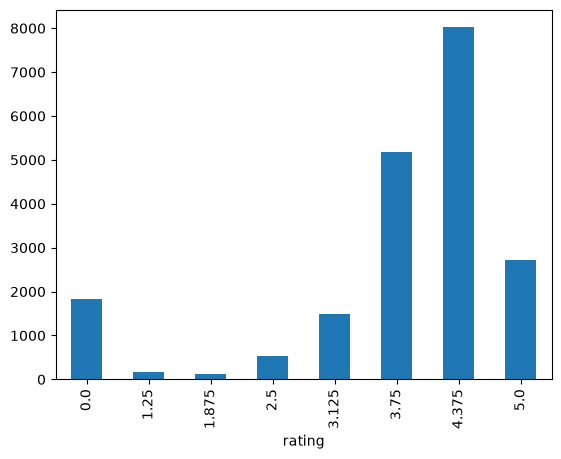

In [42]:
df['rating'].value_counts().sort_index().plot(kind='bar')

In [43]:
X = df.drop('rating', axis=1)
y = df['rating']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

## Выбор моделей

### Линейные модели

#### Ridge

In [57]:
param_grid_ridge = {
    'alpha': range(23, 28, 1),
    'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'saga']
}

ridge_search = GridSearchCV(
    Ridge(),
    param_grid=param_grid_ridge,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

ridge_search.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': range(23, 28), 'solver': ['auto', 'svd', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to desig

In [58]:
res_ridge = pd.DataFrame(ridge_search.cv_results_).sort_values('rank_test_score')
print(ridge_search.best_params_)
res_ridge.head(5)

{'alpha': 25, 'solver': 'lsqr'}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,param_solver,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
13,0.176855,0.005244,0.009533,0.000515,25,lsqr,"{'alpha': 25, 'solver': 'lsqr'}",-1.287968,-1.238184,-1.297719,-1.294022,-1.260133,-1.275605,0.022894,1
10,0.127693,0.002809,0.009377,0.000631,25,auto,"{'alpha': 25, 'solver': 'auto'}",-1.287936,-1.238218,-1.297730,-1.294013,-1.260141,-1.275608,0.022880,2
11,0.616848,0.023639,0.012250,0.002772,25,svd,"{'alpha': 25, 'solver': 'svd'}",-1.287936,-1.238218,-1.297730,-1.294013,-1.260141,-1.275608,0.022880,2
12,0.129826,0.007145,0.011684,0.002614,25,cholesky,"{'alpha': 25, 'solver': 'cholesky'}",-1.287936,-1.238218,-1.297730,-1.294013,-1.260141,-1.275608,0.022880,2
14,0.726731,0.057006,0.009860,0.000791,25,saga,"{'alpha': 25, 'solver': 'saga'}",-1.287937,-1.238219,-1.297730,-1.294013,-1.260141,-1.275608,0.022879,5


In [61]:
ridge = Ridge(**ridge_search.best_params_)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

1.2935342649260704


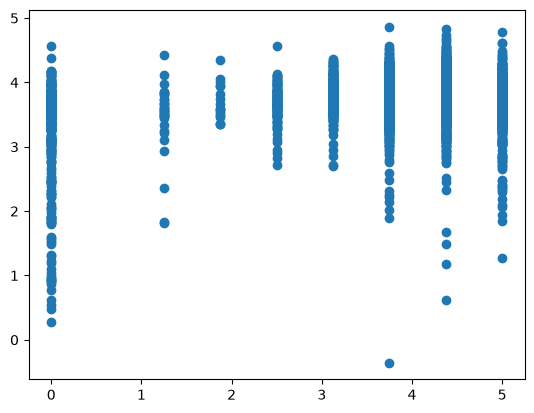

In [62]:
print(root_mean_squared_error(y_test, ridge_pred))
plt.scatter(y_test, ridge_pred)

#### Lasso

In [ ]:
param_grid_lasso = {
    'alpha': [0, 0.001, 0.005, 0.01],
    'max_iter' : [5000]
}

lasso_search = GridSearchCV(
    Lasso(),
    param_grid=param_grid_lasso,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

lasso_search.fit(X_train, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Lasso()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0, 0.001, ...], 'max_iter': [5000, 10000]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a

In [67]:
res_lasso = pd.DataFrame(lasso_search.cv_results_).sort_values('rank_test_score')
print(lasso_search.best_params_)
res_lasso.head(5)

{'alpha': 0.001, 'max_iter': 5000}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,param_max_iter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
3,0.102993,0.001697,0.010228,0.000836,0.001,10000,"{'alpha': 0.001, 'max_iter': 10000}",-1.292478,-1.242379,-1.299460,-1.295676,-1.261703,-1.278339,0.022434,1
2,0.106104,0.008042,0.010688,0.001248,0.001,5000,"{'alpha': 0.001, 'max_iter': 5000}",-1.292478,-1.242379,-1.299460,-1.295676,-1.261703,-1.278339,0.022434,1
1,0.116313,0.001758,0.010254,0.000587,0.000,10000,"{'alpha': 0, 'max_iter': 10000}",-1.291457,-1.250226,-1.304500,-1.295403,-1.277675,-1.283852,0.018902,3
0,0.116863,0.004785,0.010335,0.001073,0.000,5000,"{'alpha': 0, 'max_iter': 5000}",-1.291457,-1.250226,-1.304500,-1.295403,-1.277675,-1.283852,0.018902,3
4,0.091335,0.001838,0.009715,0.000509,0.005,5000,"{'alpha': 0.005, 'max_iter': 5000}",-1.312691,-1.259027,-1.316845,-1.311294,-1.281306,-1.296233,0.022493,5


In [68]:
lasso = Lasso(**lasso_search.best_params_)
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)

1.2955901852211946


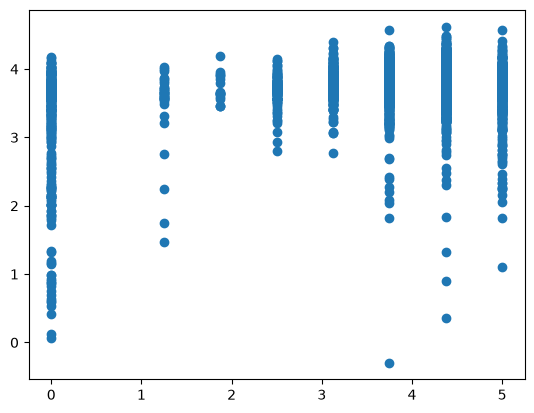

In [69]:
print(root_mean_squared_error(y_test, lasso_pred))
plt.scatter(y_test, lasso_pred)

#### ElasticNet

In [72]:
param_grid_enet = {
    'alpha': [0, 0.0001, 0.001, 0.01],
    'l1_ratio': [0.001, 0.01, 0.1],
    'max_iter': [5000]
}

enet_search = GridSearchCV(
    ElasticNet(),
    param_grid=param_grid_enet,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

enet_search.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",ElasticNet()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0, 0.0001, ...], 'l1_ratio': [0.001, 0.01, ...], 'max_iter': [5000]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_d

In [73]:
res_enet = pd.DataFrame(enet_search.cv_results_).sort_values('rank_test_score')
print(enet_search.best_params_)
res_enet.head(5)

{'alpha': 0.001, 'l1_ratio': 0.1, 'max_iter': 5000}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,param_l1_ratio,param_max_iter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
8,0.109051,0.003748,0.009863,0.000610,0.0010,0.100,5000,"{'alpha': 0.001, 'l1_ratio': 0.1, 'max_iter': ...",-1.287933,-1.238875,-1.298748,-1.293815,-1.260152,-1.275905,0.022832,1
7,0.119485,0.006037,0.010414,0.000709,0.0010,0.010,5000,"{'alpha': 0.001, 'l1_ratio': 0.01, 'max_iter':...",-1.287603,-1.238846,-1.299072,-1.293887,-1.260478,-1.275977,0.022840,2
6,0.138170,0.009512,0.010519,0.001235,0.0010,0.001,5000,"{'alpha': 0.001, 'l1_ratio': 0.001, 'max_iter'...",-1.287569,-1.238861,-1.299109,-1.293918,-1.260531,-1.275998,0.022836,3
5,0.129684,0.009238,0.010616,0.000957,0.0001,0.100,5000,"{'alpha': 0.0001, 'l1_ratio': 0.1, 'max_iter':...",-1.289455,-1.245325,-1.302791,-1.295020,-1.267152,-1.279949,0.020985,4
4,0.148519,0.008713,0.010532,0.000403,0.0001,0.010,5000,"{'alpha': 0.0001, 'l1_ratio': 0.01, 'max_iter'...",-1.289450,-1.245276,-1.302895,-1.295124,-1.267151,-1.279979,0.021038,5


In [74]:
enet = ElasticNet(**enet_search.best_params_)
enet.fit(X_train, y_train)
enet_pred = enet.predict(X_test)

1.2930473182342768


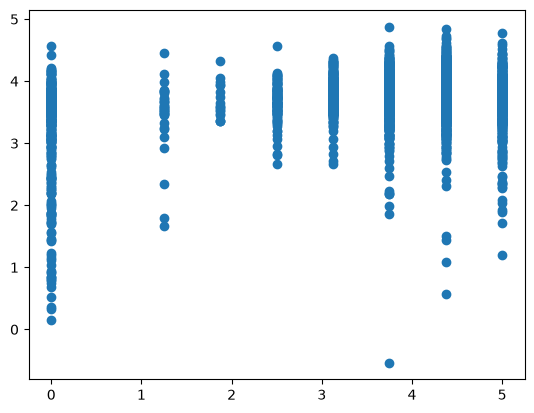

In [75]:
print(root_mean_squared_error(y_test, enet_pred))
plt.scatter(y_test, enet_pred)